# CSC 525 Project — Step 1: Data Setup & EDA

**Project:** Automated Bridge Surface Crack Detection using UAV Imagery and Deep Learning Segmentation

**Goal of this notebook:** Mount Google Drive, unzip the dataset, and perform exploratory data analysis (EDA) on the UAV crack segmentation dataset from Kaggle.

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Verify we can see the project folder
!ls '/content/drive/MyDrive/bridge_crack_detection/'

 archive.zip  'UAV-based crack dataset used for segmentation'


## 2. Unzip dataset

In [3]:
import os
import zipfile

ZIP_PATH = '/content/drive/MyDrive/bridge_crack_detection/archive.zip'
EXTRACT_DIR = '/content/data'

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

print('Extraction complete.')
!ls '/content/data'

Extraction complete.
'UAV-based crack dataset used for segmentation'


In [4]:
# Set up clean paths to images and masks
DATA_ROOT = '/content/data/UAV-based crack dataset used for segmentation'
IMG_DIR = os.path.join(DATA_ROOT, 'image')
MASK_DIR = os.path.join(DATA_ROOT, 'masks')

assert os.path.isdir(IMG_DIR), f'Missing image dir: {IMG_DIR}'
assert os.path.isdir(MASK_DIR), f'Missing mask dir: {MASK_DIR}'
print(f'Image dir: {IMG_DIR}')
print(f'Mask dir : {MASK_DIR}')

Image dir: /content/data/UAV-based crack dataset used for segmentation/image
Mask dir : /content/data/UAV-based crack dataset used for segmentation/masks


## 3. Basic dataset stats

In [5]:
img_files = sorted(os.listdir(IMG_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print(f'Number of images: {len(img_files)}')
print(f'Number of masks : {len(mask_files)}')
print(f'Filenames match : {img_files == mask_files}')

# File extensions present
exts = {os.path.splitext(f)[1].lower() for f in img_files}
print(f'Image extensions: {exts}')

Number of images: 315
Number of masks : 315
Filenames match : True
Image extensions: {'.png'}


In [6]:
# Filename prefix groups — this tells us how the data is organized.
# (The presentation claimed '30 bridges' — let's see what groupings actually exist.)
from collections import Counter

def prefix(fname):
    stem = os.path.splitext(fname)[0]
    return ''.join(c for c in stem if not c.isdigit())

groups = Counter(prefix(f) for f in img_files)
print('Filename prefix groups:')
for k, v in groups.most_common():
    print(f'  {k!r:10s}: {v} files')

Filename prefix groups:
  'slide'   : 306 files
  'DJI'     : 9 files


There is no metadata grouping images by source bridge. Filenames split into two prefix families (`slide*` and `DJI*`) but don't correspond to 30 distinct bridges.

## 4. Image and mask properties

In [7]:
import numpy as np
from PIL import Image

# Walk through every image/mask pair once and collect stats.
img_sizes = []
img_modes = []
mask_sizes = []
mask_modes = []
crack_fractions = []  # fraction of pixels that are crack (nonzero) per image
mask_unique_values = set()

for fname in img_files:
    img = Image.open(os.path.join(IMG_DIR, fname))
    msk = Image.open(os.path.join(MASK_DIR, fname))
    img_sizes.append(img.size)
    img_modes.append(img.mode)
    mask_sizes.append(msk.size)
    mask_modes.append(msk.mode)
    arr = np.array(msk)
    mask_unique_values.update(np.unique(arr).tolist())
    crack_fractions.append((arr > 0).mean())

crack_fractions = np.array(crack_fractions)
print(f'Unique image sizes : {set(img_sizes)}')
print(f'Unique image modes : {set(img_modes)}')
print(f'Unique mask sizes  : {set(mask_sizes)}')
print(f'Unique mask modes  : {set(mask_modes)}')
print(f'Unique mask values : {sorted(mask_unique_values)}')
print()
print('Crack pixel fraction per image:')
print(f'  min    : {crack_fractions.min():.4f}')
print(f'  median : {np.median(crack_fractions):.4f}')
print(f'  mean   : {crack_fractions.mean():.4f}')
print(f'  max    : {crack_fractions.max():.4f}')

Unique image sizes : {(448, 448)}
Unique image modes : {'RGBA', 'RGB'}
Unique mask sizes  : {(448, 448)}
Unique mask modes  : {'RGBA', 'L'}
Unique mask values : [0, 159, 160, 191, 255]

Crack pixel fraction per image:
  min    : 0.0009
  median : 0.0093
  mean   : 0.0148
  max    : 0.2554


**Key observations:**
- All images are the same size, no tiling is needed.
- Masks are binary (0 = background, 255 = crack).
- The crack-pixel class is heavily underrepresented per image justifying the BCE + Dice loss and recall/IoU as the right metrics.

## 5. Distribution of crack-pixel fraction

any edge-case images (e.g. no cracks at all, or cracks covering most of the image)?

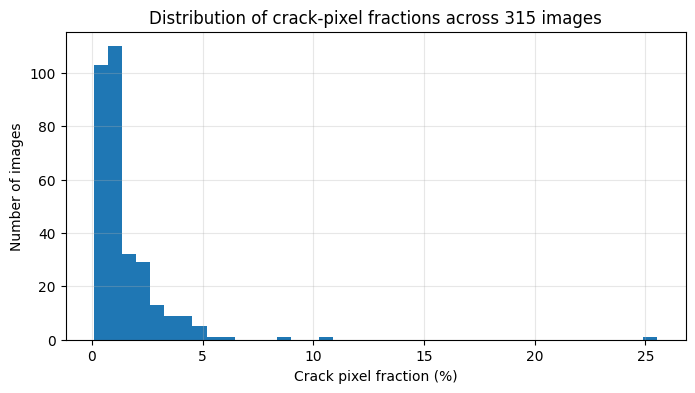

Images with no crack pixels: 0


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(crack_fractions * 100, bins=40)
plt.xlabel('Crack pixel fraction (%)')
plt.ylabel('Number of images')
plt.title(f'Distribution of crack-pixel fractions across {len(crack_fractions)} images')
plt.grid(alpha=0.3)
plt.show()

# Flag anomalies
empty_masks = [f for f, cf in zip(img_files, crack_fractions) if cf == 0]
print(f'Images with no crack pixels: {len(empty_masks)}')
if empty_masks:
    print('  Examples:', empty_masks[:5])

## 6. Visualize sample image/mask pairs
do masks actually align with cracks in the images?

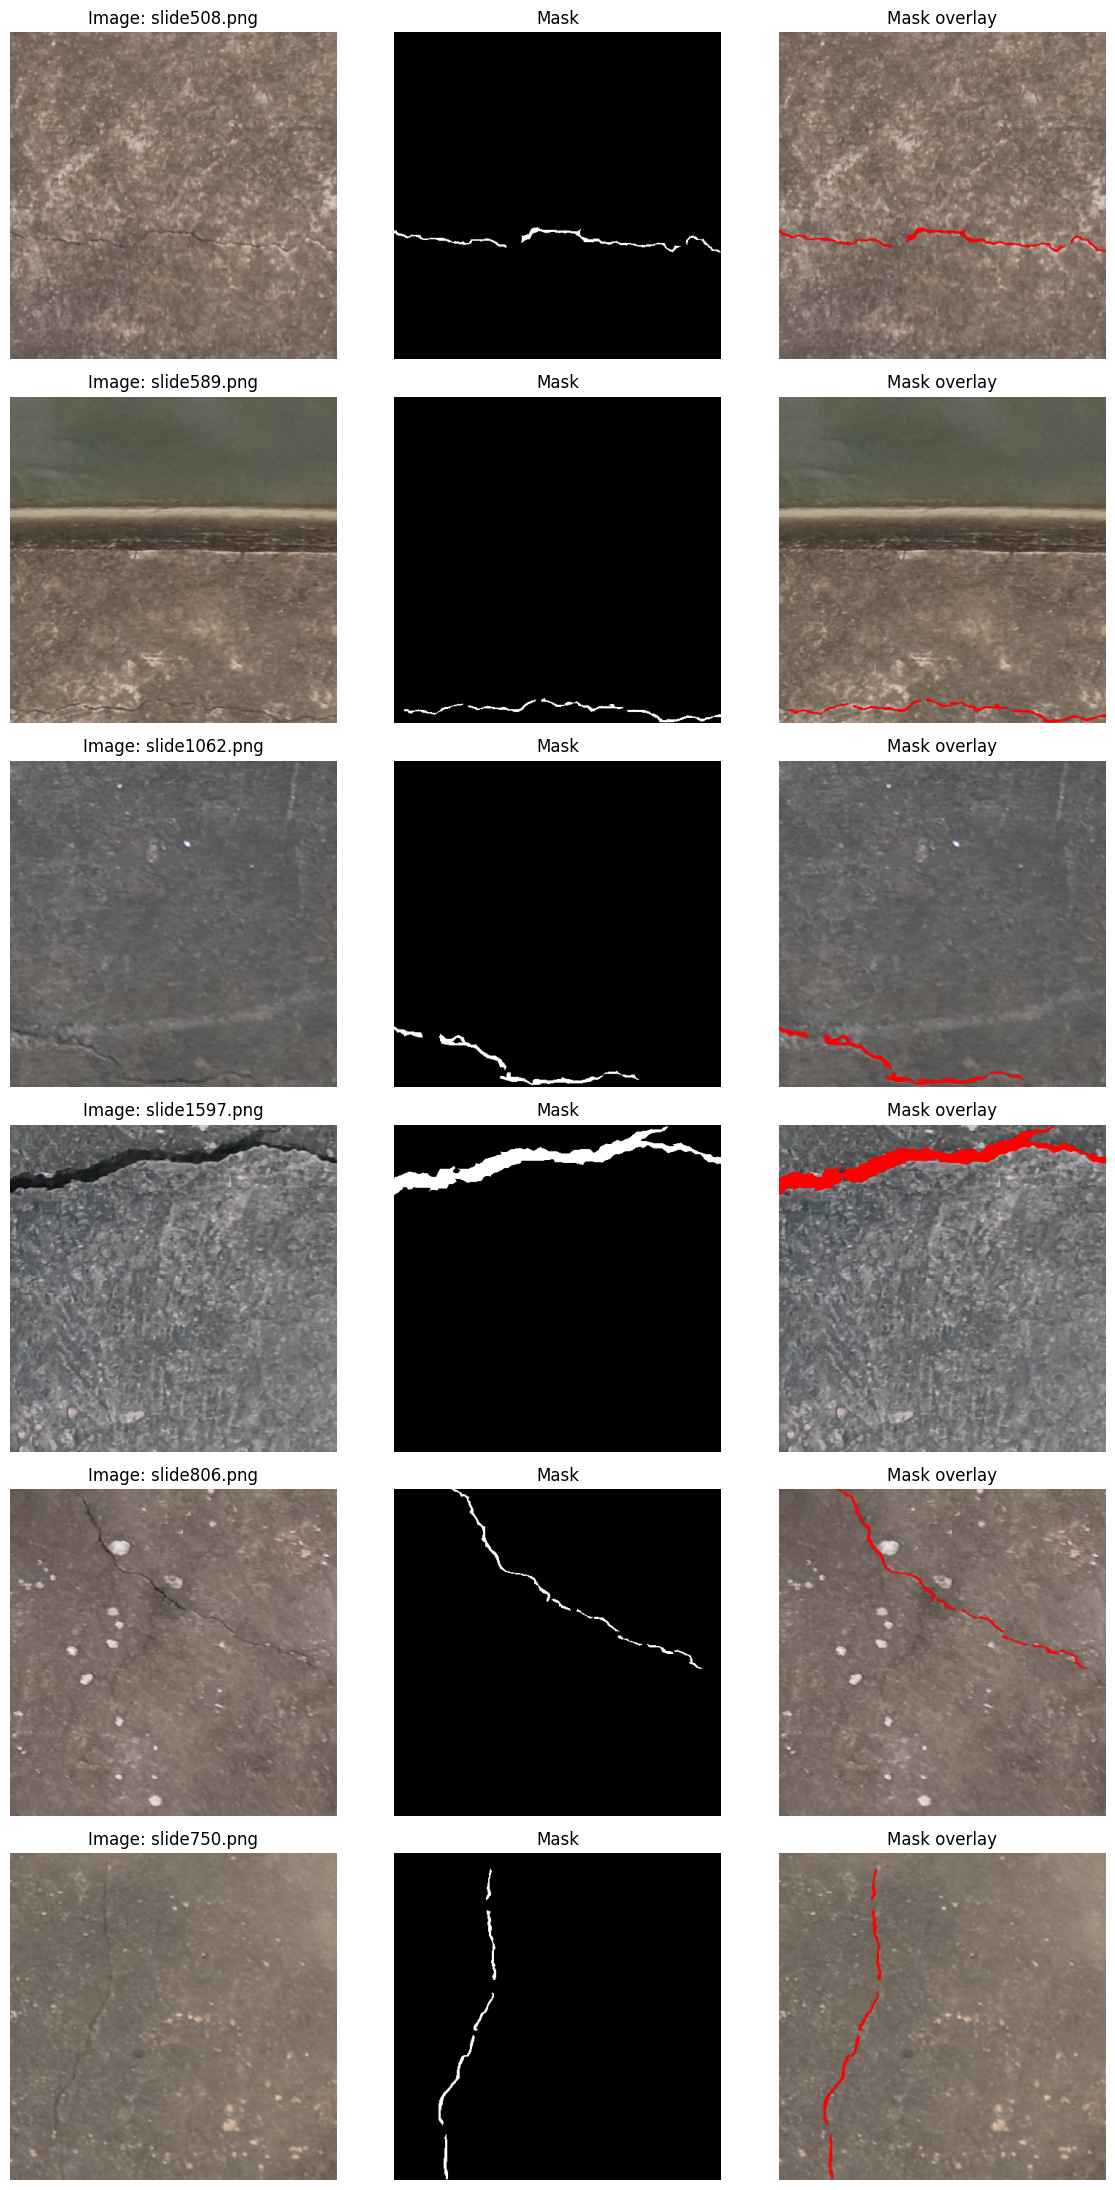

In [9]:
import random
random.seed(0)

sample_files = random.sample(img_files, 6)

fig, axes = plt.subplots(6, 3, figsize=(12, 22))
for i, fname in enumerate(sample_files):
    img = np.array(Image.open(os.path.join(IMG_DIR, fname)))
    msk = np.array(Image.open(os.path.join(MASK_DIR, fname)))

    # Create an overlay: show mask as red on top of image
    overlay = img.copy()
    overlay[msk > 0] = [255, 0, 0]

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Image: {fname}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(msk, cmap='gray')
    axes[i, 1].set_title('Mask')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title('Mask overlay')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## 7. Train / validation / test split

**70 / 15 / 15** split

In [10]:
import pandas as pd

rng = np.random.default_rng(seed=42)
shuffled = np.array(img_files)
rng.shuffle(shuffled)

n = len(shuffled)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
# test gets the rest

train_files = shuffled[:n_train]
val_files   = shuffled[n_train:n_train + n_val]
test_files  = shuffled[n_train + n_val:]

print(f'Train: {len(train_files)}')
print(f'Val  : {len(val_files)}')
print(f'Test : {len(test_files)}')

split_df = pd.DataFrame(
    [(f, 'train') for f in train_files]
    + [(f, 'val') for f in val_files]
    + [(f, 'test') for f in test_files],
    columns=['filename', 'split']
)

# Save to Drive so all teammates share the same split
split_csv_path = '/content/drive/MyDrive/bridge_crack_detection/split.csv'
split_df.to_csv(split_csv_path, index=False)
print(f'\nSplit saved to: {split_csv_path}')
split_df.head()

Train: 220
Val  : 47
Test : 48

Split saved to: /content/drive/MyDrive/bridge_crack_detection/split.csv


,filename,split
0,slide1363.png,train
1,slide1602.png,train
2,slide90.png,train
3,slide545.png,train
4,slide1144.png,train


In [11]:
# Sanity: crack-fraction distribution per split should be similar
cf_by_file = dict(zip(img_files, crack_fractions))
for split_name, files in [('train', train_files), ('val', val_files), ('test', test_files)]:
    cfs = [cf_by_file[f] for f in files]
    print(f'{split_name:5s}  n={len(cfs):3d}  mean crack frac={np.mean(cfs):.4f}  median={np.median(cfs):.4f}')

train  n=220  mean crack frac=0.0139  median=0.0093
val    n= 47  mean crack frac=0.0209  median=0.0085
test   n= 48  mean crack frac=0.0130  median=0.0099


## 8. Summary

What we confirmed in this notebook:

- **315 image/mask pairs** at 448×448 resolution, RGB images with binary (0/255) masks.
- **Mean crack-pixel fraction ≈ 1–3%** per image: severe class imbalance.
- **No bridge-level grouping** in the filenames; we split by image
- **Train/val/test = 70/15/15** split saved to `split.csv`.

## 9. Organize files by split

copy the images and masks into explicit `train`, `val`, and `test` directories within `/content/data/dataset_split/`.

In [12]:
import shutil
from tqdm.auto import tqdm

# Define the target root directory
SPLIT_ROOT = '/content/data/dataset_split'

# Create subdirectories for images and masks in each split
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(SPLIT_ROOT, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(SPLIT_ROOT, split, 'masks'), exist_ok=True)

print("Copying files into split directories...")
# Iterate through the split dataframe and copy files
for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
    fname = row['filename']
    split = row['split']

    # Source paths
    src_img = os.path.join(IMG_DIR, fname)
    src_mask = os.path.join(MASK_DIR, fname)

    # Destination paths
    dst_img = os.path.join(SPLIT_ROOT, split, 'images', fname)
    dst_mask = os.path.join(SPLIT_ROOT, split, 'masks', fname)

    # Copy files
    shutil.copy(src_img, dst_img)
    shutil.copy(src_mask, dst_mask)

print("Done! Files organized under:", SPLIT_ROOT)
!ls -lh /content/data/dataset_split/

Copying files into split directories...


  0%|          | 0/315 [00:00<?, ?it/s]

Done! Files organized under: /content/data/dataset_split
total 12K
drwxr-xr-x 4 root root 4.0K Apr 22 17:57 test
drwxr-xr-x 4 root root 4.0K Apr 22 17:57 train
drwxr-xr-x 4 root root 4.0K Apr 22 17:57 val


## 10. Save the split dataset to Google Drive

In [13]:
import shutil
import os

SPLIT_ROOT = '/content/data/dataset_split'
ZIP_TEMP_PATH = '/content/dataset_split'  # shutil.make_archive adds the .zip extension
DRIVE_DEST_PATH = '/content/drive/MyDrive/bridge_crack_detection/dataset_split.zip'

print("Zipping the dataset_split folder... (this might take a minute)")
shutil.make_archive(ZIP_TEMP_PATH, 'zip', SPLIT_ROOT)

print(f"Copying zip to Google Drive at {DRIVE_DEST_PATH}...")
shutil.copy(ZIP_TEMP_PATH + '.zip', DRIVE_DEST_PATH)

print("Done! The pre-split dataset is now safely on your Google Drive.")
!ls -lh '{DRIVE_DEST_PATH}'

Zipping the dataset_split folder... (this might take a minute)
Copying zip to Google Drive at /content/drive/MyDrive/bridge_crack_detection/dataset_split.zip...
Done! The pre-split dataset is now safely on your Google Drive.
-rw------- 1 root root 72M Apr 22 17:58 /content/drive/MyDrive/bridge_crack_detection/dataset_split.zip
